# Super-resolution using a radial mask with real data

In [14]:
import numpy as onp 
import matplotlib.pyplot as plt 
from inrmri.image_processor import reduce_FOV
from inrmri.basic_plotting import full_halph_FOV_space_time

folder = '/home/egcuevaj/repositories/SR-ST-DIP-cMRI/data/Josefa-CineLR/'
# folder = 'C:\\Users\\Legion\\OneDrive - Escuela Politécnica Nacional\\Postdoc_iHealth\\ST-DIP-SR\\repositories\\NF-cMRI\\data\\Josefa-CineLR\\'


In [15]:
# ------------------------------------------------------- # 
# Cargar los datos disponibles 
# ------------------------------------------------------- # 

import jax.numpy as np 
from inrmri.radial_acquisitions import RadialAcquisitions

print("Loading data...")

data = np.load(folder + 'sl5-data.npy')
trajs = np.load(folder + 'sl5-traj.npy')
radial_acquisition = RadialAcquisitions(trajs, data)

csmap = np.load(folder + 'sl5-csmap.npy')

# Reconstrucción con iterative sense (la reco más básica cuando se conocen las bobinas)
reco_sense = np.load(folder + 'sl5-reco-sense.npy') 

# Reconstrucción con GRASP (una reco que además de las bobinas incluye regularización (TV en tiempo))
reco_grasp = np.load(folder + 'sl5-reco-grasp.npy') 

print("Data loaded!")
print(radial_acquisition)
print(f"csmap has shape {csmap.shape}: {csmap.shape[0]} sensitivity maps of size {csmap.shape[1:3]}")
print(f"reco_sense has shape: {reco_sense.shape}: {reco_sense.shape[-1]} frames of size {reco_sense.shape[:2]}")
print(f"reco_grasp has shape: {reco_grasp.shape}: {reco_grasp.shape[-1]} frames of size {reco_grasp.shape[:2]}")

Loading data...
Data loaded!
Radial adquisition: 28 coils, 31 frames of 15 spokes each, 256 samples per spokes.
csmap has shape (28, 256, 256): 28 sensitivity maps of size (256, 256)
reco_sense has shape: (256, 256, 31): 31 frames of size (256, 256)
reco_grasp has shape: (256, 256, 31): 31 frames of size (256, 256)


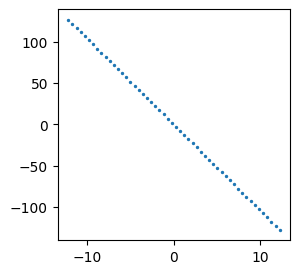

In [28]:
# Visualizar las trayectorias 

selected_frame_1 = 8

plt.figure(figsize=(3,3))
plt.scatter(
    radial_acquisition.trajs[selected_frame_1, 0, ::5, 0],
    radial_acquisition.trajs[selected_frame_1, 0, ::5, 1],
    s=2
)

In [25]:
print(radial_acquisition.data.shape)
print(radial_acquisition.trajs.shape)

(28, 31, 15, 256)
(31, 15, 256, 2)


## Super-resolution using a radial mask

In [1]:
import jax.numpy as jnp
import numpy as np
from skimage.data import shepp_logan_phantom
from skimage.transform import resize

def radial_mask(N, n_spokes=20, radius_ratio=1.0):
    """
    Create a radial k-space sampling mask (centered).
    
    Args:
        N: image dimension (N x N)
        n_spokes: number of radial lines crossing center
        radius_ratio: proportion of radius to keep (0-1)
    Returns:
        mask: (N, N) array, binary {0,1}
    """
    yy, xx = jnp.meshgrid(jnp.linspace(-1, 1, N),
                          jnp.linspace(-1, 1, N),
                          indexing='ij')
    r = jnp.sqrt(xx**2 + yy**2)
    theta = jnp.arctan2(yy, xx)

    # radial sampling lines
    mask = jnp.zeros_like(r)
    for i in range(n_spokes):
        angle = i * jnp.pi / n_spokes
        mask = jnp.logical_or(mask, jnp.abs(jnp.sin(theta - angle)) < (1.5/N))

    # circular boundary
    mask = jnp.logical_and(mask, r <= radius_ratio)
    return mask.astype(float)


In [2]:
# Fourier transform utilities
def fft2c(x):  # centered 2D FFT
    return jnp.fft.fftshift(
        jnp.fft.fft2(jnp.fft.ifftshift(x), norm="ortho")
    )

def ifft2c(k):
    return jnp.fft.fftshift(
        jnp.fft.ifft2(jnp.fft.ifftshift(k), norm="ortho")
    )


def apply_radial_mask(x, n_spokes=20, radius_ratio=1.0):
    """
    Simulate radial undersampling in k-space.
    """
    k_full = fft2c(x)
    mask = radial_mask(x.shape[0], n_spokes, radius_ratio)
    k_masked = k_full * mask
    x_reco = ifft2c(k_masked)
    return x_reco, k_masked, mask


In [3]:
# ===============================================================
# 2. Phantom and Fourier model
# ===============================================================
N = 256
phantom = shepp_logan_phantom()
x_true = resize(phantom, (N, N), anti_aliasing=True)

# Full k-space with circular mask
x_circ_full, k_circ_full, mask_full = apply_radial_mask(x_true, n_spokes=60, radius_ratio=1.0)

# Smaller (half-radius) circle for LR
x_circ_lr, k_circ_lr, mask_lr = apply_radial_mask(x_true, n_spokes=60, radius_ratio=0.5)


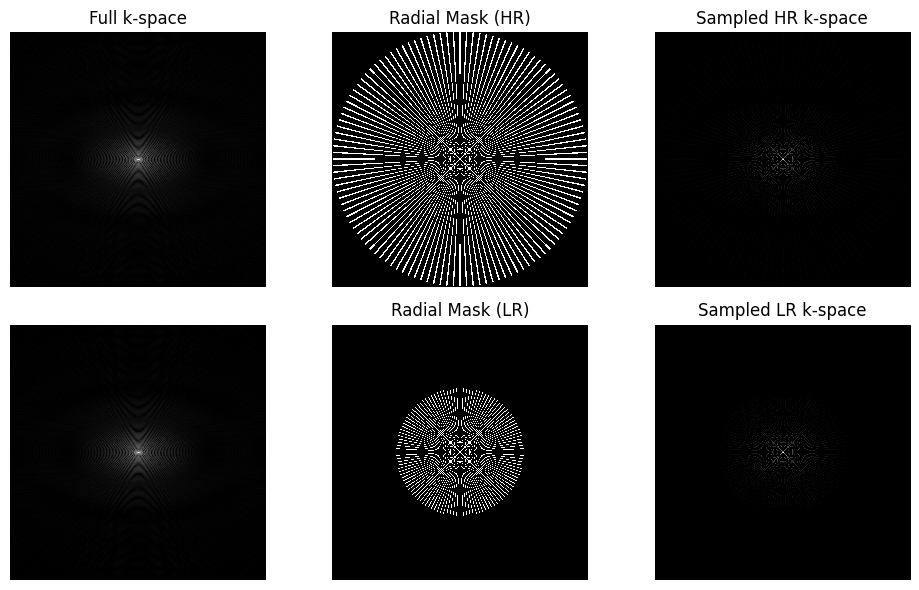

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.subplot(2, 3, 1)
plt.imshow(jnp.log1p(jnp.abs(fft2c(x_true))), cmap='gray')
plt.title("Full k-space")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(mask_full, cmap='gray')
plt.title("Radial Mask (HR)")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(jnp.log1p(jnp.abs(k_circ_full)), cmap='gray')
plt.title("Sampled HR k-space")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(jnp.log1p(jnp.abs(fft2c(x_true))), cmap='gray')
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(mask_lr, cmap='gray')
plt.title("Radial Mask (LR)")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(jnp.log1p(jnp.abs(k_circ_lr)), cmap='gray')
plt.title("Sampled LR k-space")
plt.axis("off")

plt.tight_layout()
plt.show()


In [8]:
n_spokes=15
np.sum(mask_lr)
np.sum(mask_lr)/n_spokes

Array(187.46667, dtype=float32)

In [5]:
# ===============================================================
# 1. Imports and utilities
# ===============================================================
import jax, jax.numpy as jnp
from flax import nnx
import matplotlib.pyplot as plt
import numpy as np
from skimage.data import shepp_logan_phantom
from skimage.transform import resize
import optax
from misc_nnx import downsample_sinc_image, apply_radial_mask_image, exponential_kspace_weight

In [6]:
# ===============================================================
# 2. Phantom and Fourier model
# ===============================================================
N = 256
phantom = shepp_logan_phantom()
x_true = resize(phantom, (N, N), anti_aliasing=True)

# Super-resolution factor
s = 2
N_LR = N // s
x_lr_true, k_lr_true = downsample_sinc_image(x_true, s)

# ===============================================================
# 4. Noise inputs (fixed)
# ===============================================================
key = jax.random.key(0)
z_hr = jax.random.normal(key, (256, 256)) 
z_lr, kz_lr = downsample_sinc_image(z_hr, s=2)

(-0.5, 127.5, 127.5, -0.5)

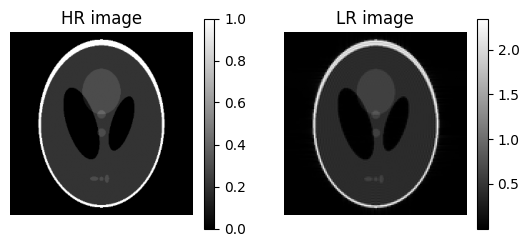

In [ ]:
plt.figure(figsize=(10, 6))

plt.subplot(2, 3, 1)
plt.imshow(x_true, cmap='gray')
plt.title("HR image")
plt.colorbar()
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(x_lr_true, cmap='gray')
plt.title("LR image")
plt.colorbar()
plt.axis("off")

In [7]:
mask_radial = radial_mask(N, n_spokes=80, radius_ratio=1.0)
mask_radial_LR = radial_mask(N_LR, n_spokes=80, radius_ratio=0.5)
W_exp = exponential_kspace_weight(N_LR, c=0.8)

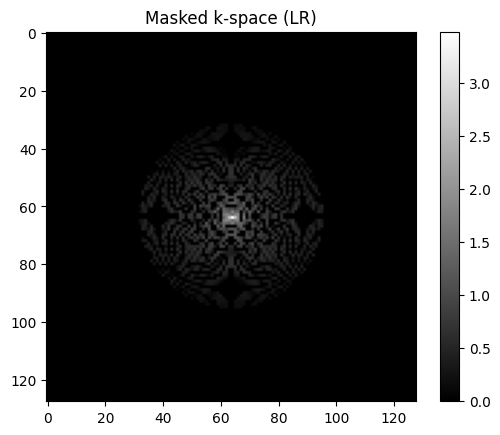

In [13]:
k_lr_test = apply_radial_mask_image(x_true, mask_radial_LR)
plt.imshow(jnp.log1p(jnp.abs(k_lr_test)), cmap='gray')
plt.title("Masked k-space (LR)")
plt.colorbar()
plt.show()

In [9]:
import numpy as np
nspokes = 80

np.sum(mask_radial_LR)/nspokes

Array(23.300001, dtype=float32)

In [10]:
from misc_nnx import charbonnier_loss, weighted_complex_mse

def loss_fn(model, beta=0.001):
    # === Forward predictions ===
    I_hr_pred = model(z_hr, training=True)[0, :, :, 0]
    k_lr_pred = apply_radial_mask_image(I_hr_pred, mask_radial_LR)

    I_lr2_pred = model(z_lr, training=True)[0, :, :, 0]
    k_lr2_pred = fft2c(I_lr2_pred) * mask_radial_LR   # same sampling pattern

    # === Losses ===
    # Unsupervised branch (consistency between predicted HR→masked LR and true LR)
    I_lr_pred,_ = downsample_sinc_image(I_hr_pred, s=2)
    L_img1 = charbonnier_loss(I_lr_pred, x_lr_true)
    L_data1 = weighted_complex_mse(
        k_lr_pred * mask_radial_LR,
        k_lr_true * mask_radial_LR,
        W_exp
    )
    L_US = L_img1 + L_data1

    # Supervised branch (direct LR prediction consistency)
    L_img2 = charbonnier_loss(I_lr2_pred, x_lr_true)
    L_data2 = weighted_complex_mse(
        k_lr2_pred * mask_radial_LR,
        k_lr_true * mask_radial_LR,
        W_exp
    )
    L_SS = beta * (L_img2 + L_data2)

    return L_SS + L_US


In [11]:
# ===============================================================
# 3. Shared decoder network
# ===============================================================
# from misc_nnx import DecoderNNX  # the one we fixed before
from misc_nnx import UNetDIP

key = jax.random.key(0)
model = UNetDIP(in_channels=1, out_channels=1, features=(32,64,128,256), rngs=nnx.Rngs(key))

In [12]:
# ===============================================================
# 6. Optimizer
# ===============================================================
optimizer = nnx.Optimizer(
    model=model,
    tx=optax.adam(1e-3),
    wrt=nnx.Param
)

z_hr = z_hr[None, : , :, None]
z_lr = z_lr[None, : , :, None]

Step     0, Loss: 5.3331e-01


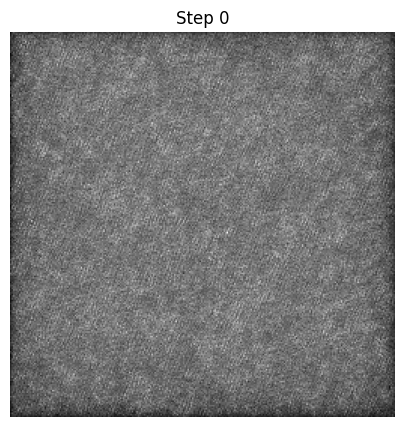

Step    10, Loss: 3.9098e-01
Step    20, Loss: 3.8508e-01
Step    30, Loss: 3.8746e-01
Step    40, Loss: 3.8388e-01
Step    50, Loss: 3.9083e-01
Step    60, Loss: 3.8501e-01
Step    70, Loss: 3.8475e-01
Step    80, Loss: 3.8325e-01
Step    90, Loss: 3.7152e-01
Step   100, Loss: 3.8495e-01
Step   110, Loss: 3.8341e-01
Step   120, Loss: 3.8183e-01
Step   130, Loss: 3.7960e-01
Step   140, Loss: 3.6437e-01
Step   150, Loss: 3.7241e-01
Step   160, Loss: 4.1417e-01
Step   170, Loss: 3.2134e-01
Step   180, Loss: 2.5612e-01
Step   190, Loss: 2.4406e-01
Step   200, Loss: 2.4043e-01
Step   210, Loss: 2.2832e-01
Step   220, Loss: 2.2910e-01
Step   230, Loss: 2.6089e-01
Step   240, Loss: 2.1013e-01
Step   250, Loss: 1.8569e-01


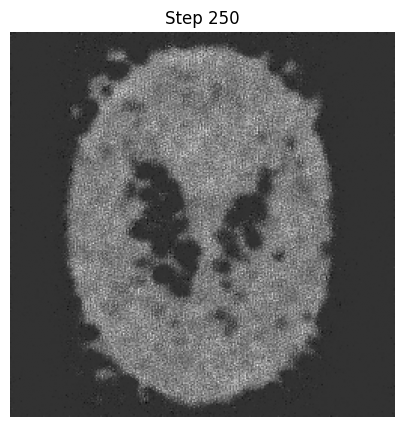

Step   260, Loss: 1.7370e-01
Step   270, Loss: 1.5642e-01
Step   280, Loss: 1.4606e-01
Step   290, Loss: 1.2786e-01
Step   300, Loss: 1.4269e-01
Step   310, Loss: 1.2209e-01
Step   320, Loss: 8.8891e-02
Step   330, Loss: 6.2671e-02
Step   340, Loss: 5.6762e-02
Step   350, Loss: 7.3372e-02
Step   360, Loss: 4.7517e-02
Step   370, Loss: 4.0041e-02
Step   380, Loss: 3.6354e-02
Step   390, Loss: 3.7524e-02
Step   400, Loss: 3.7525e-02
Step   410, Loss: 3.5252e-02
Step   420, Loss: 3.1669e-02
Step   430, Loss: 3.1616e-02
Step   440, Loss: 2.9276e-02
Step   450, Loss: 2.7585e-02
Step   460, Loss: 2.7379e-02
Step   470, Loss: 2.7855e-02
Step   480, Loss: 2.6696e-02
Step   490, Loss: 2.6285e-02
Step   500, Loss: 2.4982e-02


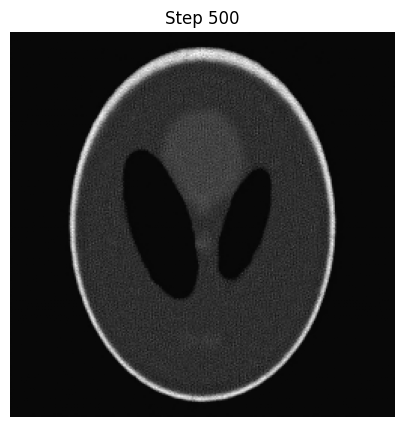

Step   510, Loss: 2.5489e-02
Step   520, Loss: 2.9772e-02
Step   530, Loss: 2.3312e-02
Step   540, Loss: 2.4655e-02
Step   550, Loss: 2.3114e-02
Step   560, Loss: 2.3888e-02
Step   570, Loss: 2.1370e-02
Step   580, Loss: 2.4458e-02
Step   590, Loss: 2.3520e-02
Step   600, Loss: 2.1700e-02
Step   610, Loss: 2.1376e-02
Step   620, Loss: 1.9924e-02
Step   630, Loss: 2.0311e-02
Step   640, Loss: 2.0394e-02
Step   650, Loss: 2.3089e-02
Step   660, Loss: 2.0273e-02
Step   670, Loss: 1.9629e-02
Step   680, Loss: 1.8944e-02
Step   690, Loss: 2.0278e-02
Step   700, Loss: 1.9448e-02
Step   710, Loss: 1.8672e-02
Step   720, Loss: 1.7878e-02
Step   730, Loss: 1.7839e-02
Step   740, Loss: 1.7130e-02
Step   750, Loss: 1.6461e-02


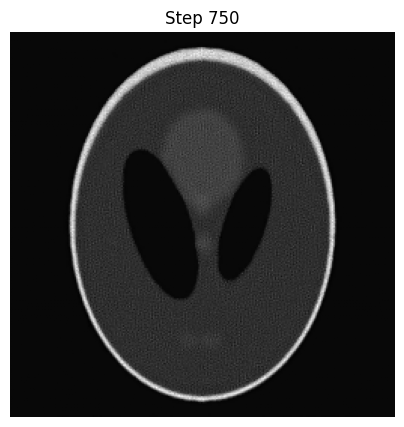

Step   760, Loss: 1.6154e-02
Step   770, Loss: 1.7209e-02
Step   780, Loss: 2.2606e-02
Step   790, Loss: 1.9084e-02
Step   800, Loss: 1.8364e-02
Step   810, Loss: 1.6724e-02
Step   820, Loss: 1.8244e-02
Step   830, Loss: 1.6536e-02
Step   840, Loss: 1.5224e-02
Step   850, Loss: 1.4445e-02
Step   860, Loss: 1.4453e-02
Step   870, Loss: 1.4788e-02
Step   880, Loss: 1.5010e-02
Step   890, Loss: 1.5524e-02
Step   900, Loss: 1.3633e-02
Step   910, Loss: 1.5293e-02
Step   920, Loss: 1.4612e-02
Step   930, Loss: 1.7338e-02
Step   940, Loss: 1.2741e-02
Step   950, Loss: 1.5783e-02
Step   960, Loss: 1.5858e-02
Step   970, Loss: 1.2931e-02
Step   980, Loss: 1.3712e-02
Step   990, Loss: 1.4447e-02
Step  1000, Loss: 1.2180e-02


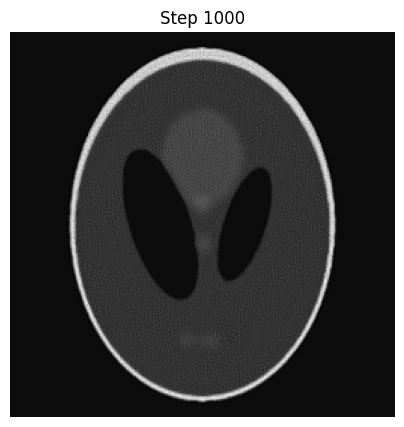

Step  1010, Loss: 1.2026e-02
Step  1020, Loss: 1.1432e-02
Step  1030, Loss: 1.1168e-02
Step  1040, Loss: 1.5252e-02
Step  1050, Loss: 1.1121e-02
Step  1060, Loss: 1.1049e-02
Step  1070, Loss: 1.2025e-02
Step  1080, Loss: 1.2606e-02
Step  1090, Loss: 1.0675e-02
Step  1100, Loss: 1.1007e-02
Step  1110, Loss: 1.1383e-02
Step  1120, Loss: 1.2653e-02
Step  1130, Loss: 1.2376e-02
Step  1140, Loss: 1.1084e-02
Step  1150, Loss: 1.0771e-02
Step  1160, Loss: 9.7270e-03
Step  1170, Loss: 1.0096e-02
Step  1180, Loss: 1.1833e-02
Step  1190, Loss: 1.0279e-02
Step  1200, Loss: 1.0229e-02
Step  1210, Loss: 1.0879e-02
Step  1220, Loss: 9.8481e-03
Step  1230, Loss: 9.7806e-03
Step  1240, Loss: 9.5426e-03
Step  1250, Loss: 9.3427e-03


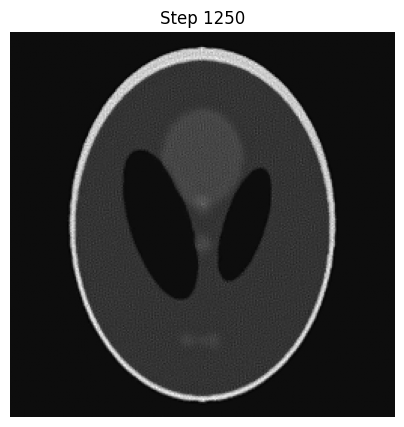

Step  1260, Loss: 9.0689e-03
Step  1270, Loss: 1.1389e-02
Step  1280, Loss: 1.0499e-02
Step  1290, Loss: 9.9057e-03
Step  1300, Loss: 8.9181e-03
Step  1310, Loss: 1.0752e-02
Step  1320, Loss: 1.0957e-02
Step  1330, Loss: 1.1234e-02
Step  1340, Loss: 8.9356e-03
Step  1350, Loss: 1.0762e-02
Step  1360, Loss: 9.4677e-03
Step  1370, Loss: 8.1960e-03
Step  1380, Loss: 1.0592e-02
Step  1390, Loss: 9.5580e-03
Step  1400, Loss: 8.6176e-03
Step  1410, Loss: 8.3564e-03
Step  1420, Loss: 1.0404e-02
Step  1430, Loss: 8.1587e-03
Step  1440, Loss: 9.9593e-03
Step  1450, Loss: 8.6545e-03
Step  1460, Loss: 8.2605e-03
Step  1470, Loss: 7.8685e-03
Step  1480, Loss: 1.0645e-02
Step  1490, Loss: 7.8581e-03
Step  1500, Loss: 7.9308e-03


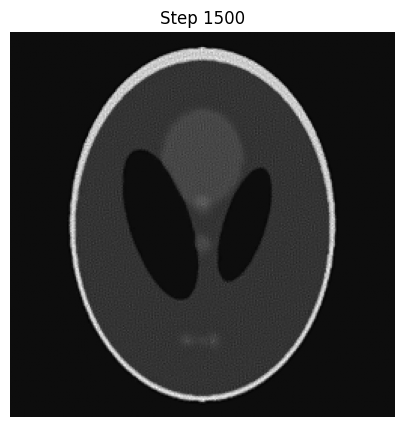

Step  1510, Loss: 1.0182e-02
Step  1520, Loss: 8.2183e-03
Step  1530, Loss: 9.7065e-03
Step  1540, Loss: 8.8529e-03
Step  1550, Loss: 8.0174e-03
Step  1560, Loss: 7.3663e-03
Step  1570, Loss: 7.5459e-03
Step  1580, Loss: 7.1227e-03
Step  1590, Loss: 8.8741e-03
Step  1600, Loss: 7.9932e-03
Step  1610, Loss: 9.0010e-03
Step  1620, Loss: 8.4734e-03
Step  1630, Loss: 9.1070e-03
Step  1640, Loss: 6.8385e-03
Step  1650, Loss: 7.7632e-03
Step  1660, Loss: 8.0144e-03
Step  1670, Loss: 9.6801e-03
Step  1680, Loss: 8.1552e-03
Step  1690, Loss: 8.2708e-03
Step  1700, Loss: 6.8721e-03
Step  1710, Loss: 8.2068e-03
Step  1720, Loss: 7.7582e-03
Step  1730, Loss: 8.6679e-03
Step  1740, Loss: 6.9261e-03
Step  1750, Loss: 6.7033e-03


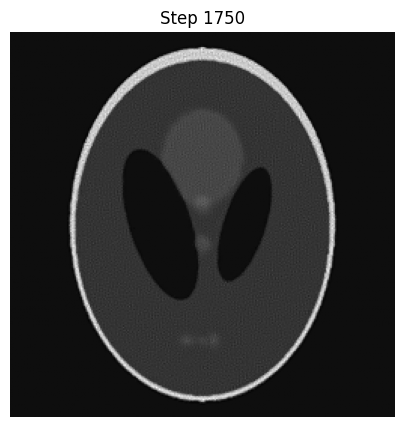

Step  1760, Loss: 1.0353e-02
Step  1770, Loss: 6.8049e-03
Step  1780, Loss: 9.3713e-03
Step  1790, Loss: 6.7720e-03
Step  1800, Loss: 1.0938e-02
Step  1810, Loss: 9.9009e-03
Step  1820, Loss: 9.0810e-03
Step  1830, Loss: 8.2817e-03
Step  1840, Loss: 7.6227e-03
Step  1850, Loss: 6.5484e-03
Step  1860, Loss: 7.5141e-03
Step  1870, Loss: 8.9667e-03
Step  1880, Loss: 8.4720e-03
Step  1890, Loss: 6.2940e-03
Step  1900, Loss: 8.4571e-03
Step  1910, Loss: 7.8668e-03
Step  1920, Loss: 7.4850e-03
Step  1930, Loss: 9.8125e-03
Step  1940, Loss: 8.1499e-03
Step  1950, Loss: 5.9595e-03
Step  1960, Loss: 7.3773e-03
Step  1970, Loss: 6.4105e-03
Step  1980, Loss: 7.7482e-03
Step  1990, Loss: 6.9952e-03
Step  2000, Loss: 8.8324e-03


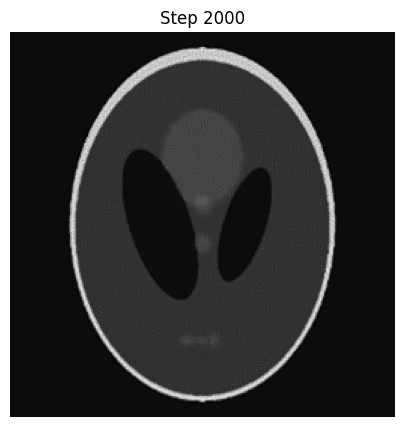

Step  2010, Loss: 6.9329e-03
Step  2020, Loss: 7.4169e-03
Step  2030, Loss: 6.5744e-03
Step  2040, Loss: 9.0712e-03
Step  2050, Loss: 6.9891e-03
Step  2060, Loss: 7.0606e-03
Step  2070, Loss: 8.0317e-03
Step  2080, Loss: 7.4592e-03
Step  2090, Loss: 8.6670e-03
Step  2100, Loss: 8.4189e-03
Step  2110, Loss: 6.9524e-03
Step  2120, Loss: 6.4719e-03
Step  2130, Loss: 6.6970e-03
Step  2140, Loss: 8.1105e-03
Step  2150, Loss: 6.1404e-03
Step  2160, Loss: 6.9089e-03
Step  2170, Loss: 7.5306e-03
Step  2180, Loss: 9.1121e-03
Step  2190, Loss: 5.8125e-03
Step  2200, Loss: 6.1264e-03
Step  2210, Loss: 7.6474e-03
Step  2220, Loss: 5.1080e-03
Step  2230, Loss: 6.0345e-03
Step  2240, Loss: 5.4028e-03
Step  2250, Loss: 5.9684e-03


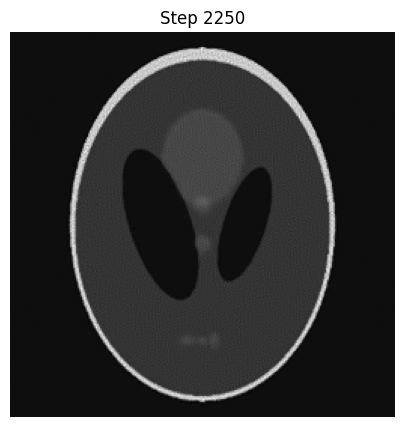

Step  2260, Loss: 5.8796e-03
Step  2270, Loss: 9.7189e-03
Step  2280, Loss: 1.1102e-02
Step  2290, Loss: 6.2448e-03
Step  2300, Loss: 7.2781e-03
Step  2310, Loss: 9.0331e-03
Step  2320, Loss: 5.8163e-03
Step  2330, Loss: 7.2932e-03
Step  2340, Loss: 6.6309e-03
Step  2350, Loss: 6.3165e-03
Step  2360, Loss: 6.0338e-03
Step  2370, Loss: 5.7264e-03
Step  2380, Loss: 5.1953e-03
Step  2390, Loss: 5.5700e-03
Step  2400, Loss: 5.2092e-03
Step  2410, Loss: 5.1070e-03
Step  2420, Loss: 5.5767e-03
Step  2430, Loss: 4.9684e-03
Step  2440, Loss: 6.2379e-03
Step  2450, Loss: 5.3426e-03
Step  2460, Loss: 5.5402e-03
Step  2470, Loss: 5.2377e-03
Step  2480, Loss: 5.7328e-03
Step  2490, Loss: 1.4033e-02
Step  2500, Loss: 4.3146e-01


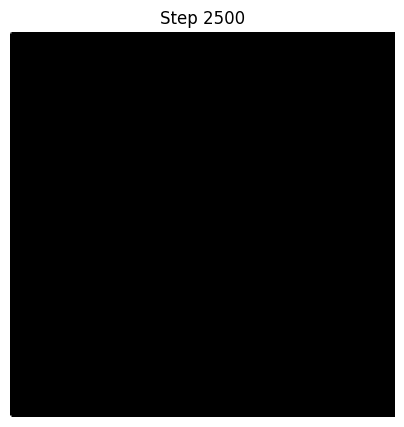

Step  2510, Loss: 4.3145e-01
Step  2520, Loss: 4.3140e-01
Step  2530, Loss: 4.3126e-01
Step  2540, Loss: 4.3122e-01
Step  2550, Loss: 4.3122e-01
Step  2560, Loss: 4.3122e-01
Step  2570, Loss: 4.3122e-01
Step  2580, Loss: 4.3122e-01
Step  2590, Loss: 4.3122e-01
Step  2600, Loss: 4.3122e-01
Step  2610, Loss: 4.3122e-01
Step  2620, Loss: 4.3122e-01
Step  2630, Loss: 4.3122e-01
Step  2640, Loss: 4.3122e-01
Step  2650, Loss: 4.3122e-01
Step  2660, Loss: 4.3122e-01
Step  2670, Loss: 4.3122e-01
Step  2680, Loss: 4.3122e-01
Step  2690, Loss: 4.3122e-01
Step  2700, Loss: 4.3122e-01
Step  2710, Loss: 4.3122e-01
Step  2720, Loss: 4.3122e-01
Step  2730, Loss: 4.3122e-01
Step  2740, Loss: 4.3122e-01
Step  2750, Loss: 4.3122e-01


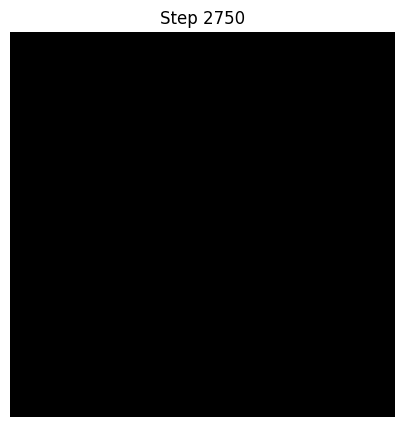

Step  2760, Loss: 4.3122e-01
Step  2770, Loss: 4.3122e-01
Step  2780, Loss: 4.3122e-01
Step  2790, Loss: 4.3122e-01
Step  2800, Loss: 4.3122e-01
Step  2810, Loss: 4.3122e-01
Step  2820, Loss: 4.3122e-01
Step  2830, Loss: 4.3122e-01
Step  2840, Loss: 4.3122e-01
Step  2850, Loss: 4.3122e-01
Step  2860, Loss: 4.3122e-01
Step  2870, Loss: 4.3122e-01
Step  2880, Loss: 4.3122e-01
Step  2890, Loss: 4.3122e-01
Step  2900, Loss: 4.3122e-01
Step  2910, Loss: 4.3122e-01
Step  2920, Loss: 4.3122e-01
Step  2930, Loss: 4.3122e-01
Step  2940, Loss: 4.3122e-01
Step  2950, Loss: 4.3122e-01
Step  2960, Loss: 4.3122e-01
Step  2970, Loss: 4.3122e-01
Step  2980, Loss: 4.3122e-01
Step  2990, Loss: 4.3122e-01
Step  3000, Loss: 4.3122e-01


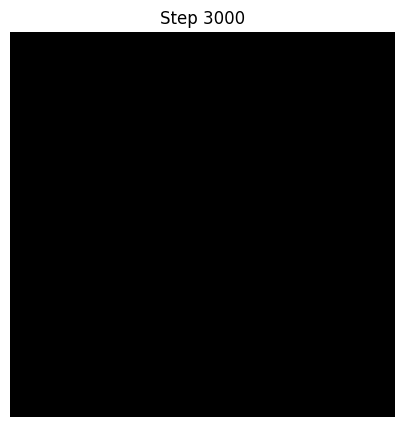

Step  3010, Loss: 4.3122e-01
Step  3020, Loss: 4.3122e-01
Step  3030, Loss: 4.3122e-01
Step  3040, Loss: 4.3122e-01
Step  3050, Loss: 4.3122e-01
Step  3060, Loss: 4.3122e-01
Step  3070, Loss: 4.3122e-01
Step  3080, Loss: 4.3122e-01
Step  3090, Loss: 4.3122e-01
Step  3100, Loss: 4.3122e-01
Step  3110, Loss: 4.3122e-01
Step  3120, Loss: 4.3122e-01
Step  3130, Loss: 4.3122e-01
Step  3140, Loss: 4.3122e-01
Step  3150, Loss: 4.3122e-01
Step  3160, Loss: 4.3122e-01
Step  3170, Loss: 4.3122e-01
Step  3180, Loss: 4.3122e-01
Step  3190, Loss: 4.3122e-01
Step  3200, Loss: 4.3122e-01
Step  3210, Loss: 4.3122e-01
Step  3220, Loss: 4.3122e-01
Step  3230, Loss: 4.3122e-01
Step  3240, Loss: 4.3122e-01
Step  3250, Loss: 4.3122e-01


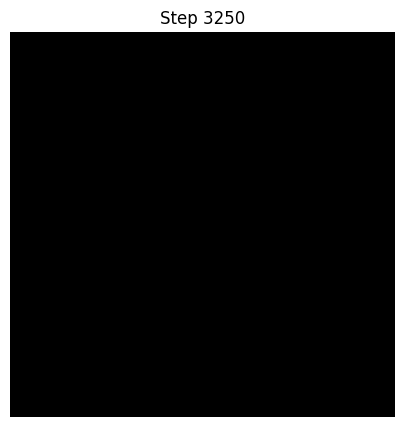

Step  3260, Loss: 4.3122e-01
Step  3270, Loss: 4.3122e-01
Step  3280, Loss: 4.3122e-01
Step  3290, Loss: 4.3122e-01
Step  3300, Loss: 4.3122e-01
Step  3310, Loss: 4.3122e-01
Step  3320, Loss: 4.3122e-01
Step  3330, Loss: 4.3122e-01
Step  3340, Loss: 4.3122e-01
Step  3350, Loss: 4.3122e-01
Step  3360, Loss: 4.3122e-01
Step  3370, Loss: 4.3122e-01
Step  3380, Loss: 4.3122e-01
Step  3390, Loss: 4.3122e-01
Step  3400, Loss: 4.3122e-01
Step  3410, Loss: 4.3122e-01
Step  3420, Loss: 4.3122e-01
Step  3430, Loss: 4.3122e-01
Step  3440, Loss: 4.3122e-01
Step  3450, Loss: 4.3122e-01
Step  3460, Loss: 4.3122e-01
Step  3470, Loss: 4.3122e-01
Step  3480, Loss: 4.3122e-01
Step  3490, Loss: 4.3122e-01
Step  3500, Loss: 4.3122e-01


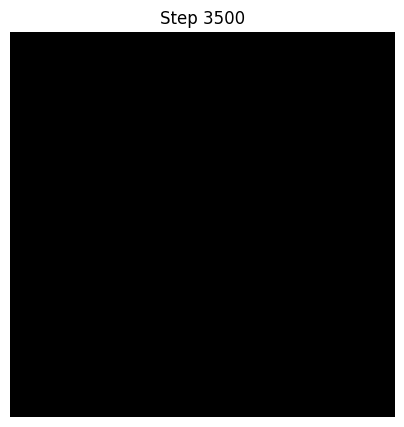

Step  3510, Loss: 4.3122e-01
Step  3520, Loss: 4.3122e-01
Step  3530, Loss: 4.3122e-01
Step  3540, Loss: 4.3122e-01
Step  3550, Loss: 4.3122e-01
Step  3560, Loss: 4.3122e-01
Step  3570, Loss: 4.3122e-01
Step  3580, Loss: 4.3122e-01
Step  3590, Loss: 4.3122e-01
Step  3600, Loss: 4.3122e-01
Step  3610, Loss: 4.3122e-01
Step  3620, Loss: 4.3122e-01
Step  3630, Loss: 4.3122e-01
Step  3640, Loss: 4.3122e-01
Step  3650, Loss: 4.3122e-01
Step  3660, Loss: 4.3122e-01
Step  3670, Loss: 4.3122e-01
Step  3680, Loss: 4.3122e-01
Step  3690, Loss: 4.3122e-01
Step  3700, Loss: 4.3122e-01
Step  3710, Loss: 4.3122e-01
Step  3720, Loss: 4.3122e-01
Step  3730, Loss: 4.3122e-01
Step  3740, Loss: 4.3122e-01
Step  3750, Loss: 4.3122e-01


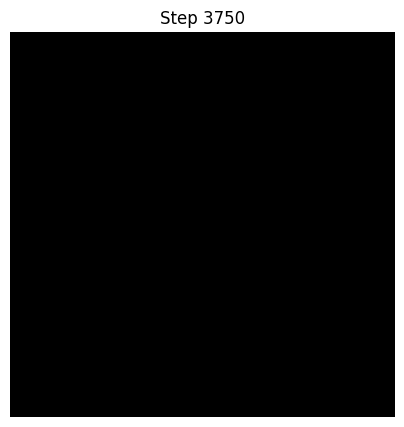

Step  3760, Loss: 4.3122e-01
Step  3770, Loss: 4.3122e-01
Step  3780, Loss: 4.3122e-01
Step  3790, Loss: 4.3122e-01
Step  3800, Loss: 4.3122e-01
Step  3810, Loss: 4.3122e-01
Step  3820, Loss: 4.3122e-01
Step  3830, Loss: 4.3122e-01
Step  3840, Loss: 4.3122e-01
Step  3850, Loss: 4.3122e-01
Step  3860, Loss: 4.3122e-01
Step  3870, Loss: 4.3122e-01
Step  3880, Loss: 4.3122e-01
Step  3890, Loss: 4.3122e-01
Step  3900, Loss: 4.3122e-01
Step  3910, Loss: 4.3122e-01
Step  3920, Loss: 4.3122e-01
Step  3930, Loss: 4.3122e-01
Step  3940, Loss: 4.3122e-01
Step  3950, Loss: 4.3122e-01
Step  3960, Loss: 4.3122e-01
Step  3970, Loss: 4.3122e-01
Step  3980, Loss: 4.3122e-01
Step  3990, Loss: 4.3122e-01
Step  4000, Loss: 4.3122e-01


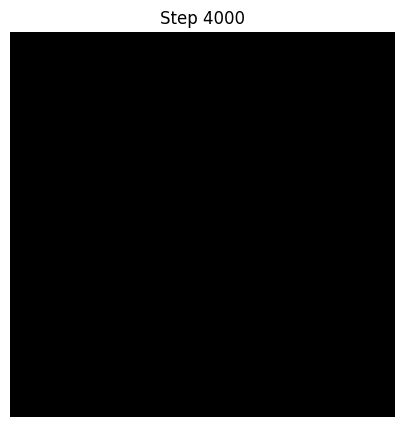

Step  4010, Loss: 4.3122e-01
Step  4020, Loss: 4.3122e-01
Step  4030, Loss: 4.3122e-01
Step  4040, Loss: 4.3122e-01
Step  4050, Loss: 4.3122e-01
Step  4060, Loss: 4.3122e-01
Step  4070, Loss: 4.3122e-01
Step  4080, Loss: 4.3122e-01
Step  4090, Loss: 4.3122e-01
Step  4100, Loss: 4.3122e-01
Step  4110, Loss: 4.3122e-01
Step  4120, Loss: 4.3122e-01
Step  4130, Loss: 4.3122e-01
Step  4140, Loss: 4.3122e-01
Step  4150, Loss: 4.3122e-01
Step  4160, Loss: 4.3122e-01
Step  4170, Loss: 4.3122e-01
Step  4180, Loss: 4.3122e-01
Step  4190, Loss: 4.3122e-01
Step  4200, Loss: 4.3122e-01
Step  4210, Loss: 4.3122e-01
Step  4220, Loss: 4.3122e-01
Step  4230, Loss: 4.3122e-01
Step  4240, Loss: 4.3122e-01
Step  4250, Loss: 4.3122e-01


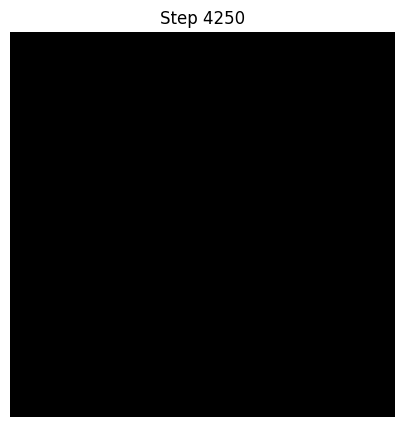

Step  4260, Loss: 4.3122e-01
Step  4270, Loss: 4.3122e-01
Step  4280, Loss: 4.3122e-01
Step  4290, Loss: 4.3122e-01
Step  4300, Loss: 4.3122e-01
Step  4310, Loss: 4.3122e-01
Step  4320, Loss: 4.3122e-01
Step  4330, Loss: 4.3122e-01
Step  4340, Loss: 4.3122e-01
Step  4350, Loss: 4.3122e-01
Step  4360, Loss: 4.3122e-01
Step  4370, Loss: 4.3122e-01


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f2c2f415e10>>
Traceback (most recent call last):
  File "/mnt/workspace/egcuevaj/.conda/envs/jaxenv/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


Step  4380, Loss: 4.3122e-01
Step  4390, Loss: 4.3122e-01
Step  4400, Loss: 4.3122e-01


In [ ]:
# ===============================================================
# 7. Training loop
# ===============================================================
n_steps = 2_500
losses = []


for step in range(n_steps):
    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(model, grads)
    losses.append(loss)

    if step % 10 == 0:
        print(f"Step {step:5d}, Loss: {float(loss):.4e}")

    if step % 250 == 0:
        I_hr_pred = model(z_hr, training=False)[0, :, :, 0]
        plt.figure(figsize=(5,5))
        plt.imshow(I_hr_pred, cmap='gray')
        plt.title(f"Step {step}")
        plt.colorbar()
        plt.axis('off')
        plt.show()